In [19]:
# Librerias necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Format pandas output to 4 decimals
pd.options.display.float_format = '{:.2f}'.format

### Data Standardization

In [ ]:
# Cargar datos
df = pd.read_csv('data.csv')
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [5]:
# Estandarizar nombres de columnas
df.columns = df.columns.str.lower().str.replace(' ', '_')
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [ ]:
# Estandarizar categorias en columnas categoricas
str_cols = df.dtypes[df.dtypes == 'str'].index.tolist()
for col in str_cols:
    df[col] = df[col].str.lower().str.replace(' ', '_')
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


### Exploratory Data Analysis

In [ ]:
# Valores nulos
df.isnull().sum()

make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3742
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
dtype: int64

In [ ]:
# Estadisticos descriptivos columnas numericas
df.describe()

,year,engine_hp,engine_cylinders,number_of_doors,highway_mpg,city_mpg,popularity,msrp
count,11914.00,11845.00,11884.00,11908.00,11914.00,11914.00,11914.00,11914.00
mean,2010.38,249.39,5.63,3.44,26.64,19.73,1554.91,40594.74
std,7.58,109.19,1.78,0.88,8.86,8.99,1441.86,60109.10
min,1990.00,55.00,0.00,2.00,12.00,7.00,2.00,2000.00
25%,2007.00,170.00,4.00,2.00,22.00,16.00,549.00,21000.00
50%,2015.00,227.00,6.00,4.00,26.00,18.00,1385.00,29995.00
75%,2016.00,300.00,6.00,4.00,30.00,22.00,2009.00,42231.25
max,2017.00,1001.00,16.00,4.00,354.00,137.00,5657.00,2065902.00


In [ ]:
# Estadisticos descriptivos columnas categoricas
df.describe(include='str')

,make,model,engine_fuel_type,transmission_type,driven_wheels,market_category,vehicle_size,vehicle_style
count,11914,11914,11911,11914,11914,8172,11914,11914
unique,48,914,10,5,4,71,3,16
top,chevrolet,silverado_1500,regular_unleaded,automatic,front_wheel_drive,crossover,compact,sedan
freq,1123,156,7172,8266,4787,1110,4764,3048


**Distribution of price**

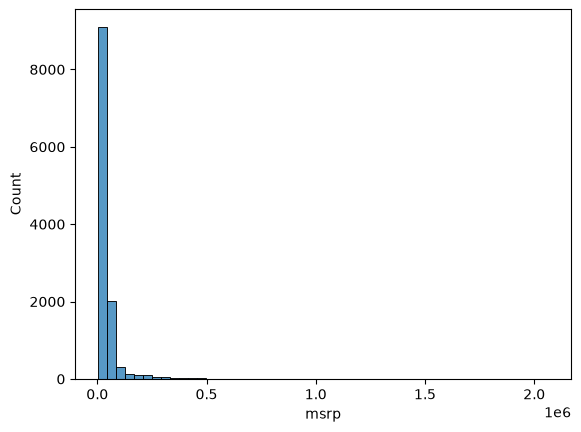

In [ ]:
# Todos los valores
sns.histplot(df['msrp'], bins=50)
plt.show()

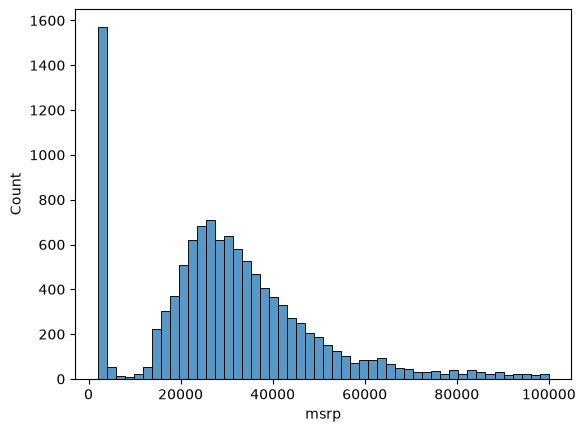

In [29]:
# Filtrando valores extremos
sns.histplot(df[df['msrp'] < 100000]['msrp'], bins=50)
plt.show()

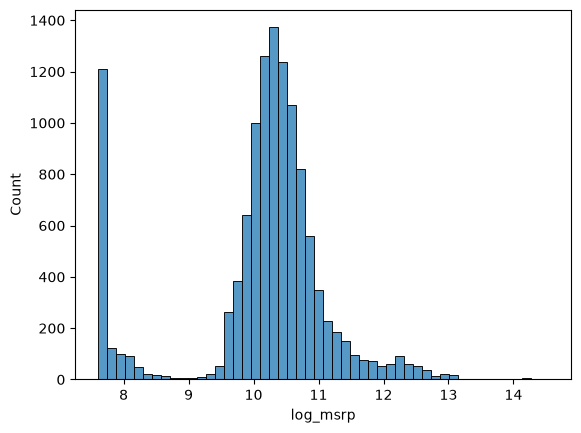

In [31]:
# Aplicar logaritmo
df['log_msrp'] = np.log1p(df['msrp'])
sns.histplot(df['log_msrp'], bins=50)
plt.show()

### Data split

In [ ]:
# Calcular porciones de train, val y test
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test
print(f'Tamaño del dataset: {n}, train: {n_train}, val: {n_val}, test: {n_test}')

Tamaño del dataset: 11914, train: 7150, val: 2382, test: 2382


In [33]:
# Separar los datos
df_train = df.iloc[:n_train]
df_val = df.iloc[n_train:n_train+n_val]
df_test = df.iloc[n_train+n_val:]

El problema con esto es que es secuencial, por lo que si los datos están ordenados de alguna manera, esto puede introducir sesgos. Por ejemplo, si los datos están ordenados por fecha, entonces el conjunto de entrenamiento podría contener solo datos antiguos y el conjunto de prueba solo datos recientes. Esto no es representativo del mundo real y puede llevar a un modelo que no generaliza bien.

In [34]:
# Shuffle manual
idx = np.arange(n)
np.random.seed(42)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train+n_val]]
df_test = df.iloc[idx[n_train+n_val:]]

len(df_train), len(df_val), len(df_test)

(7150, 2382, 2382)

In [35]:
# Resetear indices
df_train.reset_index(drop=True, inplace=True)
df_val.reset_index(drop=True, inplace=True)
df_test.reset_index(drop=True, inplace=True)

In [37]:
# Separacion de target
y_train = df_train.log_msrp.values
y_val = df_val.log_msrp.values
y_test = df_test.log_msrp.values

del df_train['log_msrp'], df_train['msrp']
del df_val['log_msrp'], df_val['msrp']
del df_test['log_msrp'], df_test['msrp']

### Regresion lineal

In [ ]:
df_train.iloc[10]

make                            toyota
model                            yaris
year                              2015
engine_fuel_type      regular_unleaded
engine_hp                       106.00
engine_cylinders                  4.00
transmission_type               manual
driven_wheels        front_wheel_drive
number_of_doors                   2.00
market_category              hatchback
vehicle_size                   compact
vehicle_style            2dr_hatchback
highway_mpg                         37
city_mpg                            30
popularity                        2031
Name: 10, dtype: object

In [40]:
#features = ['engine_hp', 'city_mpg'. 'popularity']
#xi = [106, 30, 2031]
#g(xi) ~ yi
w0 = 7.17
w = [0.01, 0.04, 0.002]
def linear_regression(xi):
    n = len(xi)
    pred = w0
    for j in range(n):
        pred += w[j] * xi[j]
    return pred

linear_regression([106, 30, 2031])

13.492

In [41]:
np.expm1(13.492)

np.float64(723603.3180935134)

### Regresion lineal (forma vectorial)

In [42]:
def dot(xi, w):
    n = len(xi)
    res = 0.0
    for j in range(n):
        res += xi[j] * w[j]
    return res

In [44]:
def linear_regression(xi):
    xi = [1] + xi
    return dot(xi, w)

In [49]:
x1 = np.array([[148, 24, 13],
      [134, 19, 14],
      [106, 30, 2031]])
w1 = np.array([7.17, 0.01, 0.04, 0.002])
linear_regression(x1)

array([7.104, 1.112, 4.804])

### Entrenar modelo de regresion lineal

In [74]:
X = [[148, 24, 1385],
     [132, 25, 2031],
     [453, 11, 86],
     [158, 24, 185],
     [172, 25, 201],
     [413, 11, 86],
     [38, 54, 185],
     [142, 25, 431],
     [453, 31, 86]
     ]
X = np.array(X)
X

array([[ 148,   24, 1385],
       [ 132,   25, 2031],
       [ 453,   11,   86],
       [ 158,   24,  185],
       [ 172,   25,  201],
       [ 413,   11,   86],
       [  38,   54,  185],
       [ 142,   25,  431],
       [ 453,   31,   86]])

In [62]:
ones = np.ones(X.shape[0])
ones

array([1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [64]:
X = np.column_stack((ones, X))

In [59]:
y = [100, 200, 150, 250, 100, 200, 150, 250, 120]

In [65]:
XTX = X.T.dot(X)
XTX_inv = np.linalg.inv(XTX)
XTX.dot(XTX_inv).round(1)

array([[ 1., -0.,  0.,  0.],
       [-0.,  1.,  0.,  0.],
       [-0.,  0.,  1.,  0.],
       [-0., -0.,  0.,  1.]])

In [69]:
w_full = XTX_inv.dot(X.T).dot(y)
w0 = w_full[0]
w = w_full[1:]
w0, w

(np.float64(300.0677669255554), array([-0.22774253, -2.5769413 , -0.02301206]))

In [72]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack((ones, X))
    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

In [75]:
train_linear_regression(X, y)

(np.float64(300.0677669255554), array([-0.22774253, -2.5769413 , -0.02301206]))

### BaselineModel

In [79]:
features = ['engine_hp', 'engine_cylinders', 'highway_mpg', 'city_mpg', 'popularity']
X_train = df_train[features].fillna(0).values

In [81]:
w0, w = train_linear_regression(X_train, y_train)

In [83]:
# Predict
y_pred = w0 + X_train.dot(w)

<Axes: ylabel='Count'>

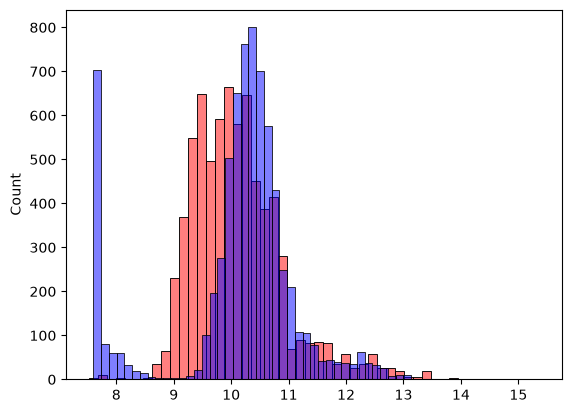

In [88]:
sns.histplot(y_pred, bins=50, color='red', alpha=0.5)
sns.histplot(y_train, bins=50, color='blue', alpha=0.5)

### RMSE

In [89]:
def calculate_rmse(y, y_pred):
    error = y - y_pred
    mse = (error ** 2).mean()
    rmse = np.sqrt(mse)
    return rmse

In [90]:
calculate_rmse(y_train, y_pred)

np.float64(0.7570200472453602)

### Validating the model

In [92]:
features = ['engine_hp', 'engine_cylinders', 'highway_mpg', 'city_mpg', 'popularity']
X_train = df_train[features].fillna(0).values
w0, w = train_linear_regression(X_train, y_train)   
y_pred = w0 + X_train.dot(w)
print(f'Train RMSE: {calculate_rmse(y_train, y_pred):.3f}')
X_val = df_val[features].fillna(0).values
y_pred = w0 + X_val.dot(w)
print(f'Validation RMSE: {calculate_rmse(y_val, y_pred):.3f}')

Train RMSE: 0.757
Validation RMSE: 0.740


### Simple feature engineering

In [93]:
def prepare_X(df):
    df = df.copy()
    
    df['age'] = 2017 - df['year']
    f = features + ['age']
    
    df_num = df[f].fillna(0)
    X = df_num.values
    return X

In [96]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

x_val = prepare_X(df_val)
y_pred = w0 + x_val.dot(w)

calculate_rmse(y_val, y_pred)

np.float64(0.5133241025826359)

### Categorical features